In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("../data/city_lifestyle_dataset.csv")

# garder uniquement numérique
X = df.select_dtypes(include=["number"]).copy()

# remplir NaN
X = X.fillna(X.median(numeric_only=True))

# standardiser
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled.shape

(300, 8)

Après sélection des variables numériques, imputation des valeurs manquantes par la médiane et standardisation des données, la matrice finale contient 300 observations décrites par 8 variables quantitatives, prêtes pour les analyses de Machine Learning.

In [3]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

X_pca[:5]

array([[-1.74319203,  0.07125072],
       [-1.64149334, -0.01498101],
       [-2.4110457 , -0.32020402],
       [-1.74815041, -0.75852822],
       [-3.07870732,  0.97171377]])

Une analyse en composantes principales (PCA) a été appliquée sur les données standardisées afin de réduire la dimension de 8 variables à 2 composantes principales. Les coordonnées obtenues représentent la projection des observations dans le plan factoriel maximisant la variance expliquée, permettant une visualisation synthétique de la structure des données.

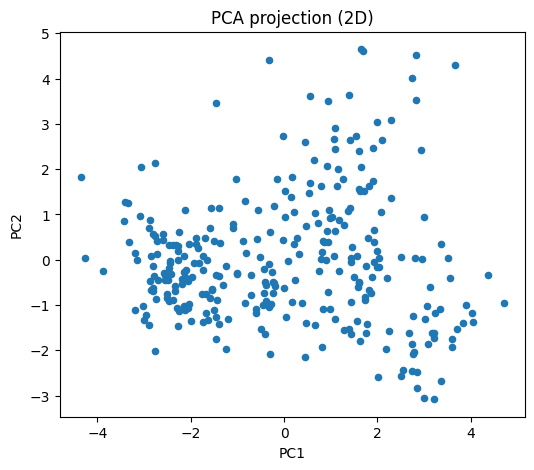

In [4]:
plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], s=20)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA projection (2D)")
plt.show()

La projection PCA en deux dimensions montre une dispersion continue des observations sans séparation nette en clusters distincts. Cela suggère que la structure des données est plutôt progressive et dominée par des corrélations linéaires entre variables, la PCA capturant principalement les directions de variance maximale plutôt que des groupes bien définis.

In [5]:
import pandas as pd

df_out = pd.DataFrame(X_pca, columns=["x","y"])
df_out.to_csv("../outputs/pca_2d.csv", index=False)

print("Exported to outputs/pca_2d.csv")

Exported to outputs/pca_2d.csv
